# Gene Expression copy number correction

June 11, 2024

## Goal:
Apply copy number correction to gene expression data

**Procedure:**
1. Load replication timing
2. Load gene expression data for all genes (may take a while, start with a smaller set)
4. Copy number correction
5. Store corrected data for deconvolution


In [213]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [214]:
from src.CopyNumberCorrection import CopyNumberCorrector

corrector = CopyNumberCorrector()
corrector.compute_replication_timing()

In [215]:
corrector.load_gene_expression_data(1)

In [222]:
corrector.correct_for_copy_number()

0/5578 - 00:00:00.003
1000/5578 - 00:00:00.302
2000/5578 - 00:00:00.603
3000/5578 - 00:00:00.905
4000/5578 - 00:00:01.210
5000/5578 - 00:00:01.514


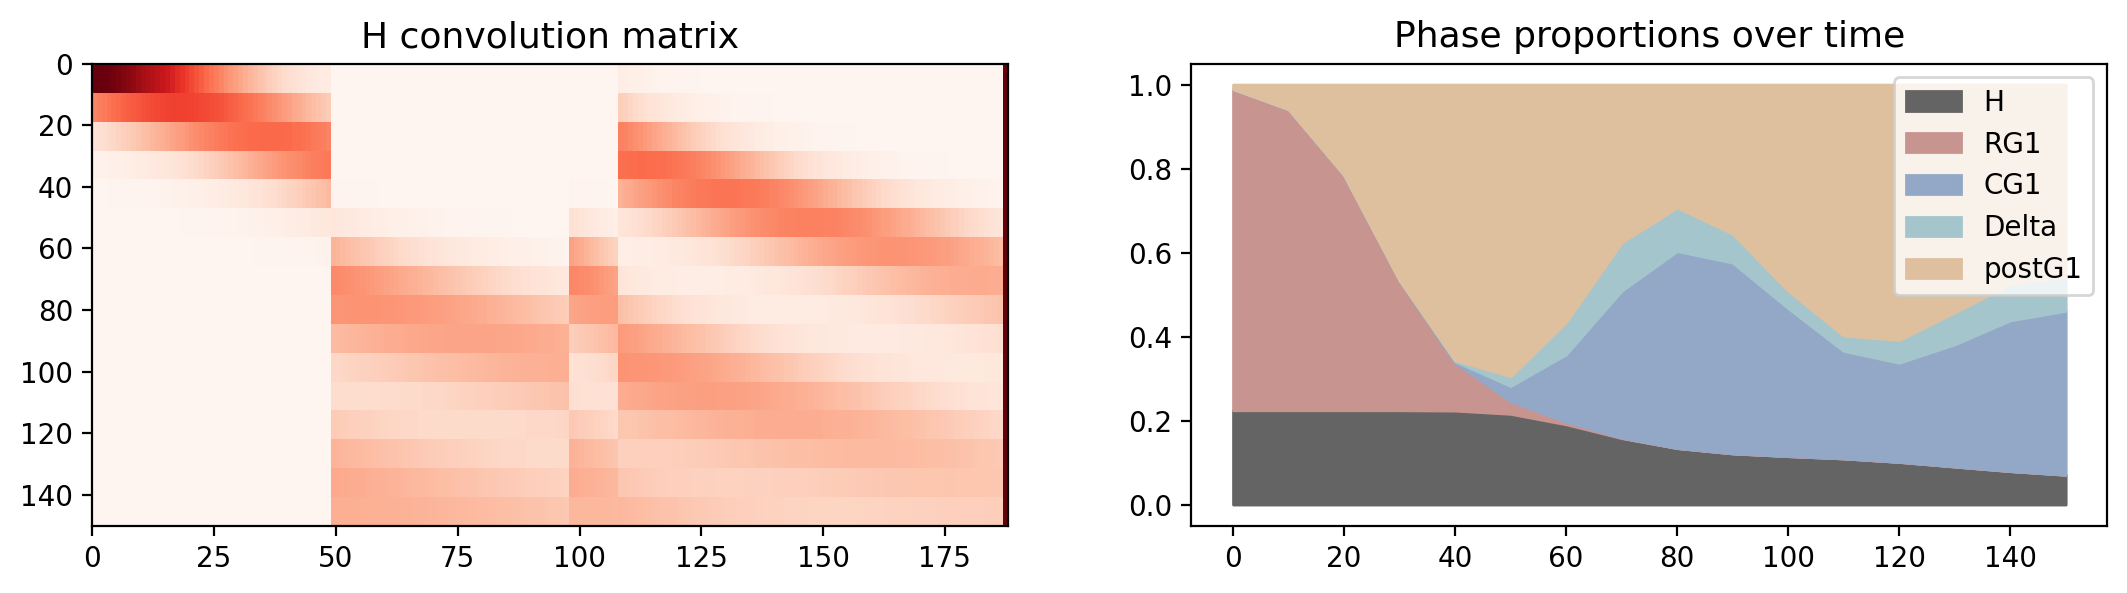

In [223]:
from src.delta_config import plot_H

plot_H(corrector.config, corrector.H)

In [224]:
corrector.compute_ptrs()

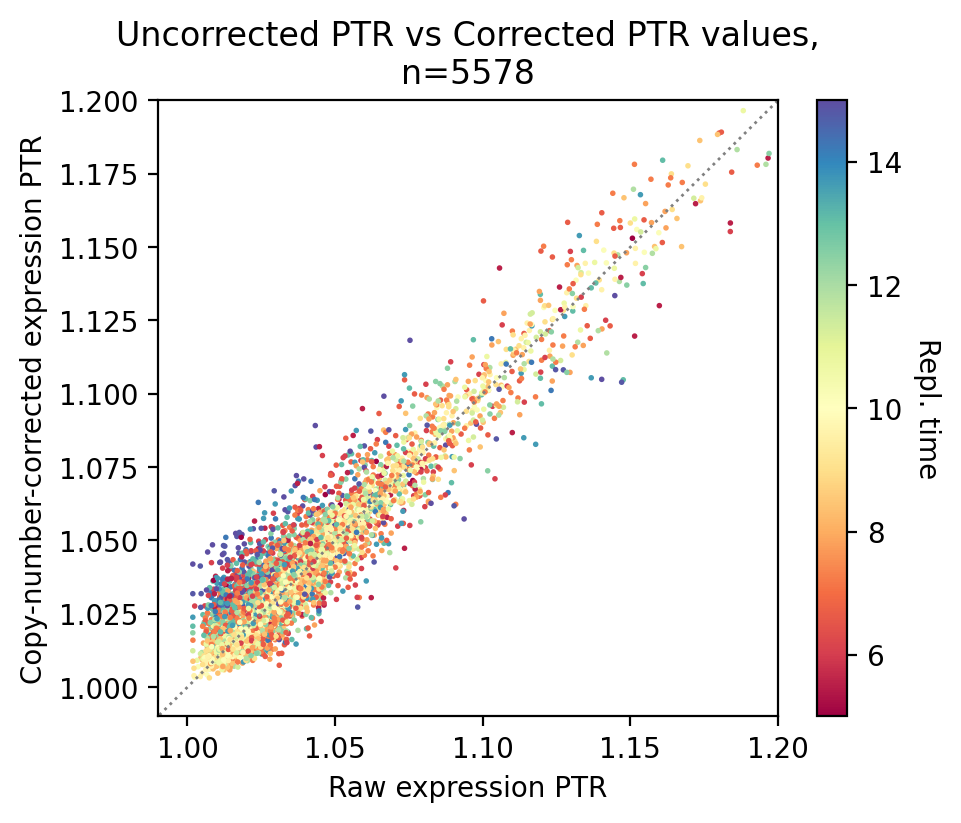

In [225]:
corrector.plot_ptrs()

In [226]:
dat = corrector.ge_comparison_ptr_df

dat[dat.corrected_ptr < 1.025].sort_values('difference')

,raw_ptr,corrected_ptr,difference,replication_time
orf_name,,,,
YMR190C,1.041343,1.017454,-0.023889,6.6724
YGL013C,1.031092,1.007448,-0.023644,6.6724
YLR003C,1.045273,1.022393,-0.022880,6.0912
YHR054C,1.036791,1.014679,-0.022112,13.6463
YFR028C,1.043038,1.021173,-0.021865,7.8347
...,...,...,...,...
YFL038C,1.006268,1.024195,0.017927,12.4840
YAR014C,1.006643,1.024799,0.018156,6.6724
YOL166W-A,1.001815,1.020766,0.018951,13.0652


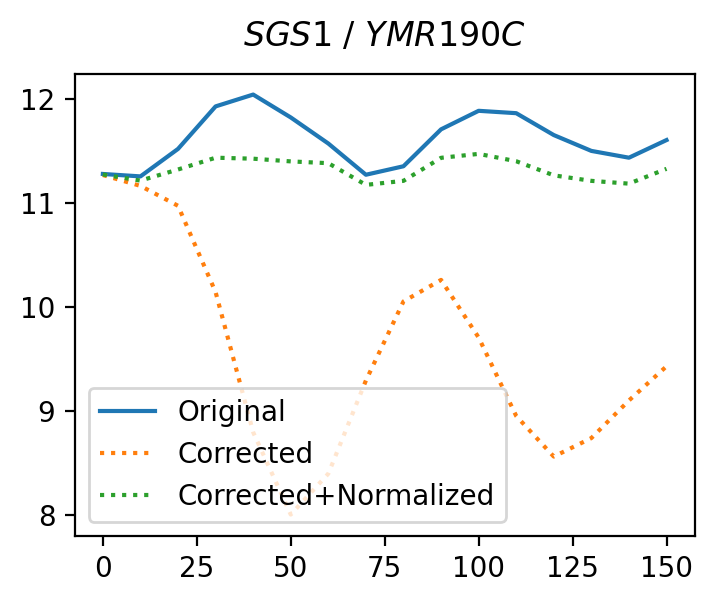

In [227]:
corrector.plot_corrected_gene('YMR190C')
